# Linear Stability 

In [90]:
import numpy as np
from matplotlib import pyplot as plt
import sys
import seaborn as sns
sns.set(style = "ticks")
from matplotlib.animation import FuncAnimation

In [5]:
del a,b,u_star,k,L,D,m,n,p,sigma1

NameError: name 'a' is not defined

In [27]:
b=1
a=0.1
u_star = (a+1)/b
k = np.linspace(-1.5,1.5,201)
m = -k**2-b+(2/u_star)
L=100
D=np.array([0,0.1,1,5,10,20,50,100])


C:\Users\troy-\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\troy-\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\troy-\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\troy-\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\troy-\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values t

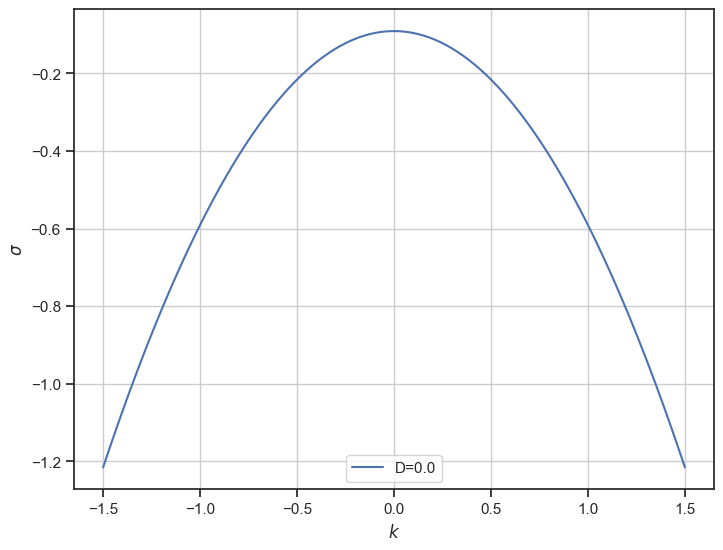

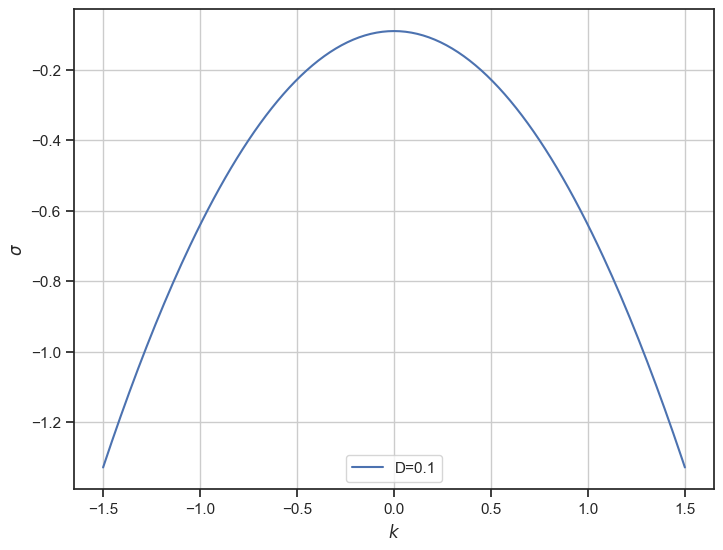

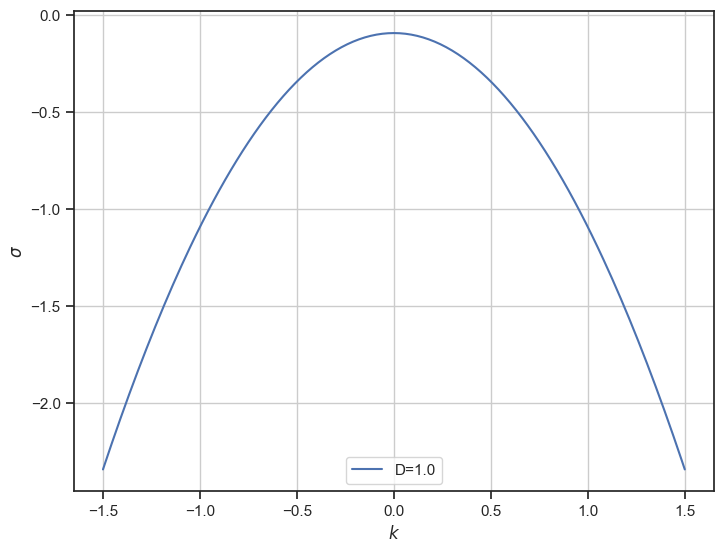

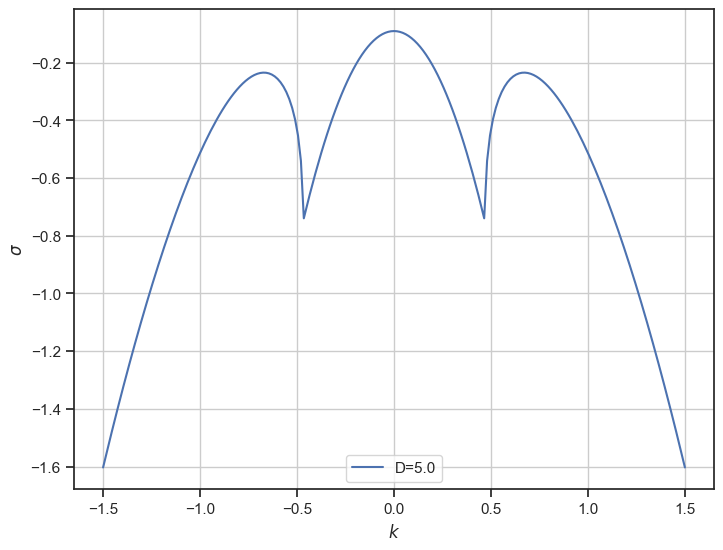

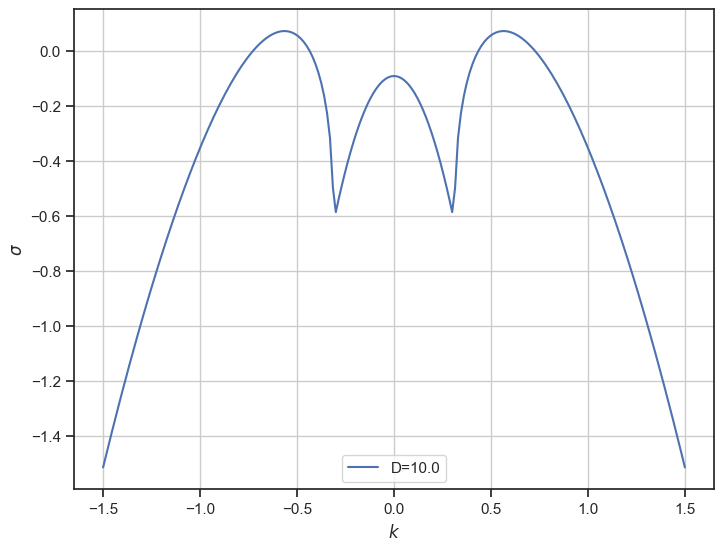

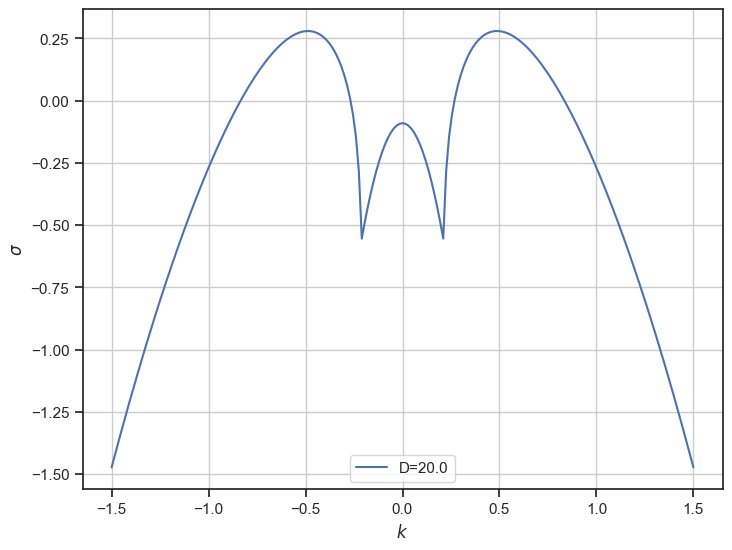

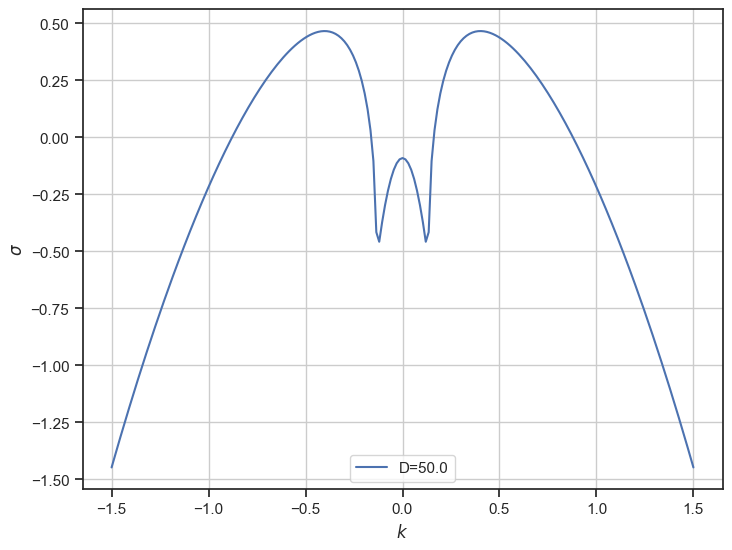

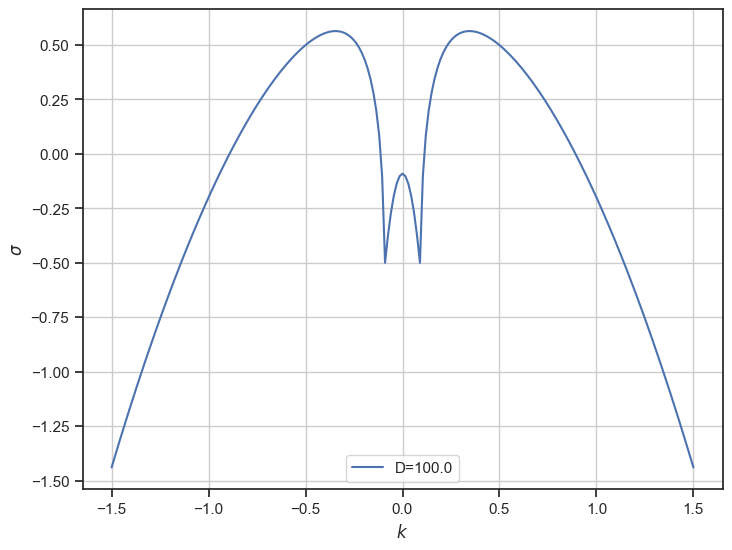

In [45]:
for d in D:
    fig = plt.figure()
    n = -d*k**2-1
    p = m+n
    sigma=(p+np.sqrt(p**2-4*(m*n+2/u_star+0j)))/2
    axes = fig.add_axes([-2,2,1,1])
    axes.plot(k,sigma)
    axes.legend(([f"D={d}"]),loc="lower center")
    axes.grid(True,which='both')
    plt.xlabel(r"$k$")
    plt.ylabel(r"$\sigma$")
    plt.savefig(f'D={d}.jpg',bbox_inches='tight')

# Getting $u^1$ and $v^1$ with Forward Euler

In [53]:
N=100
I = np.eye(N)
matrix = -2*I
 

for i in range(N-1):
    j=i+1
    matrix[i][j]=1
    matrix[j][i]=1

matrix[N-1][0]=1
matrix[0][N-1]=1


In [54]:
def n1(u,v):
    return a-b*u+u**2/v 

In [55]:
def n2(u,v):
    return u**2-v

In [56]:
def dudt(uxx,u,v):
    B = (a-b*u+n1(u,v))*I
    return np.matmul(uxx+B,u)

In [59]:
def dvdt(vxx,u,v,D):
    M = (n2(u,v)-v)*I
    return np.matmul(D*vxx+M,v)

In [137]:
k0=2*np.pi/50
X = np.arange(0,N)
ru=np.cos(k0*X)
rv=np.cos(k0*X)
u0 = u_star+ru
v0 = u_star**2+rv
delta_t = 0.01
D=100
u1=u0+delta_t*dudt(matrix,u0,v0)
v1=v0+delta_t*dvdt(matrix,u0,v0,D)


# Integrating with Crank Nicholson scheme with Adams-Bashforth scheme

In [63]:
c = delta_t/2

In [64]:
def AdamsBashforthV(U1,V1,U0,V0):
    return 3*c*n2(U1,V1)-c*n2(U0,V0)

In [65]:
def AdamsBashforthU(U1,V1,U0,V0):
    return 3*c*n1(U1,V1)-c*n1(U0,V0)

In [66]:
def CNIntegrator(U1,V1,U0,V0,L,D):
    P = np.linalg.inv(I-c*L)
    R = np.matmul((I+c*L),U1)+AdamsBashforthU(U1,V1,U0,V0)
    u = np.matmul(P,R)
    
    W = D*L
    Y = np.matmul(I+c*W,V1)+AdamsBashforthV(U1,V1,U0,V0)
    v = np.matmul(P,Y)
    return u,v

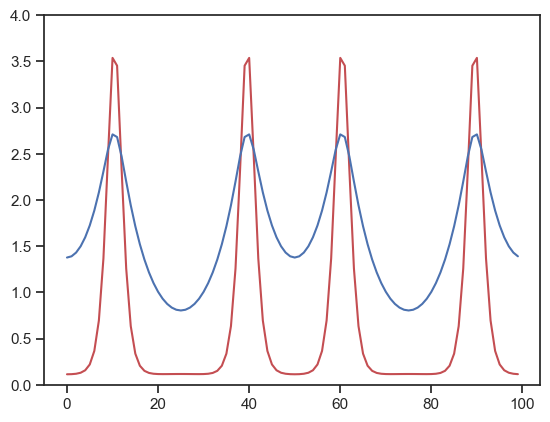

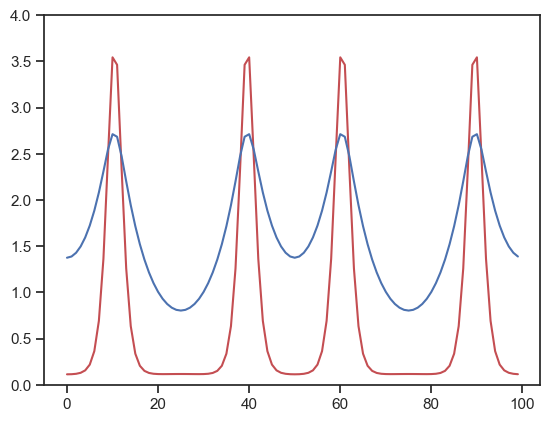

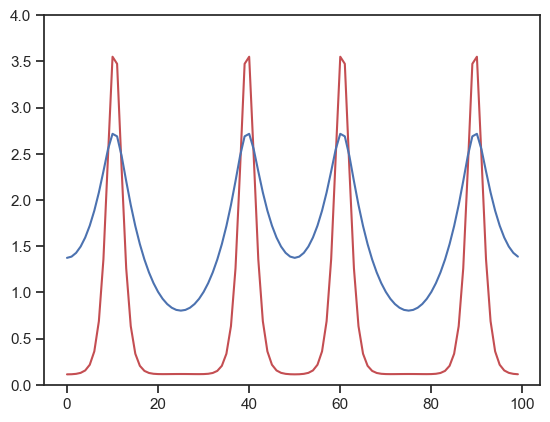

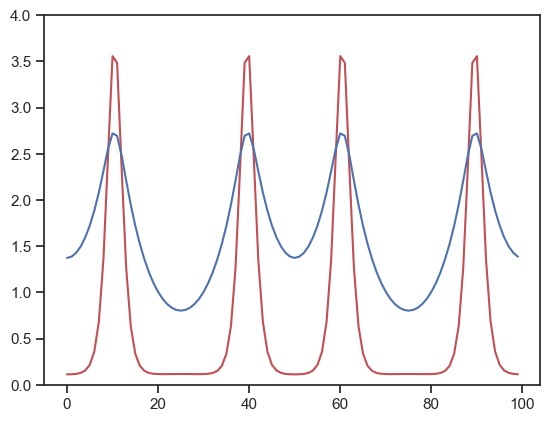

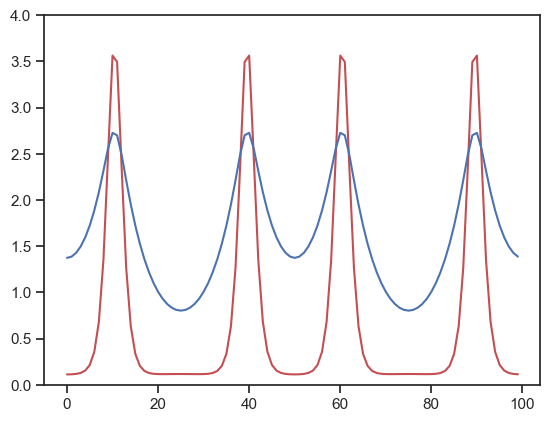

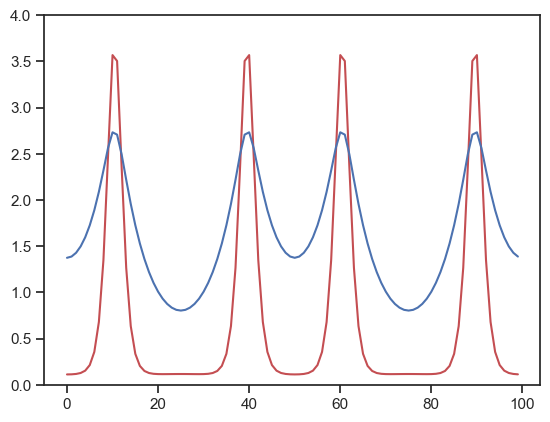

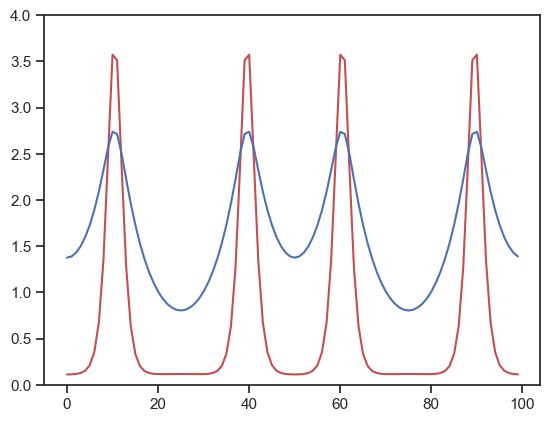

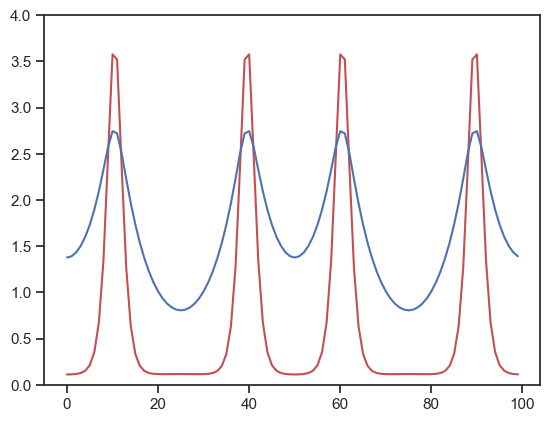

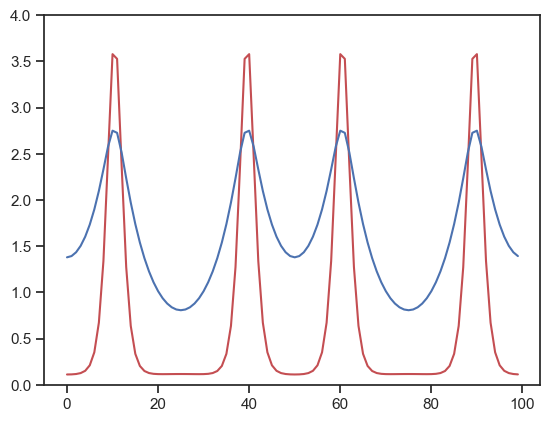

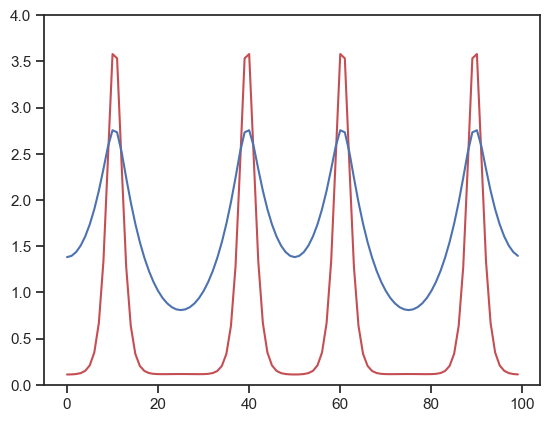

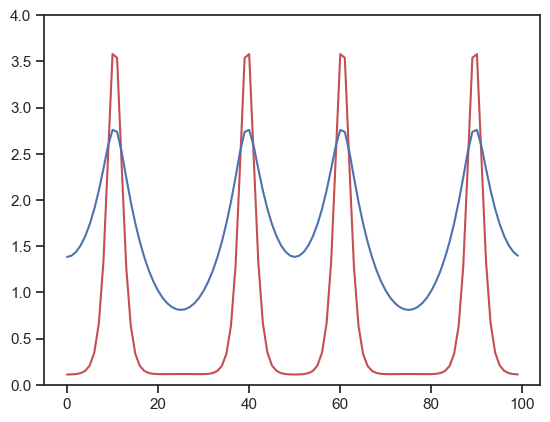

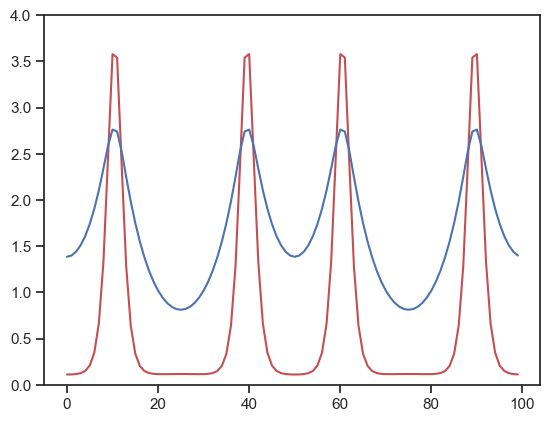

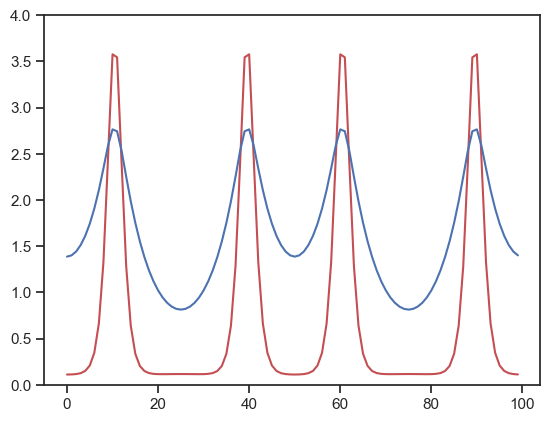

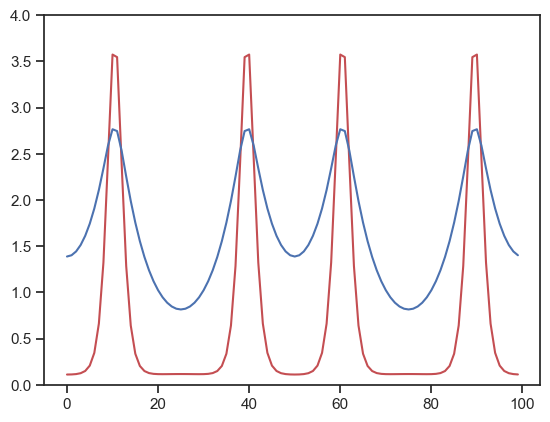

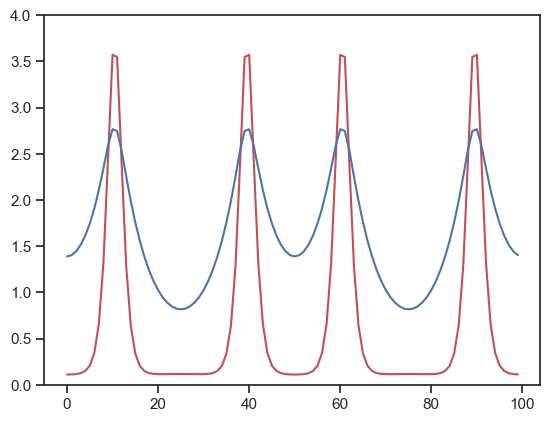

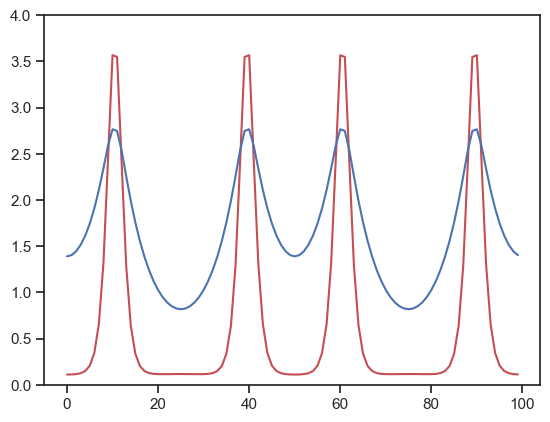

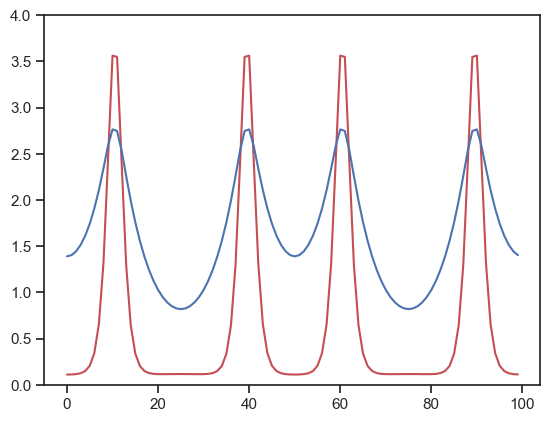

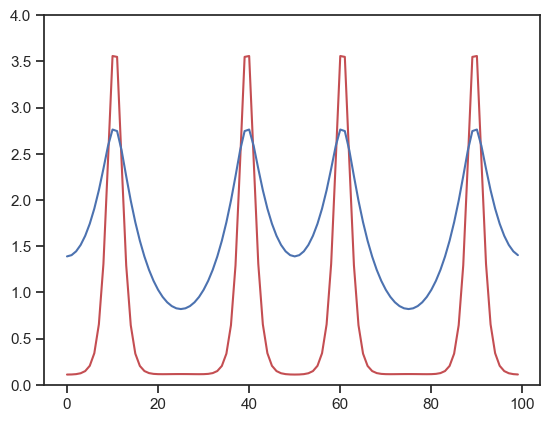

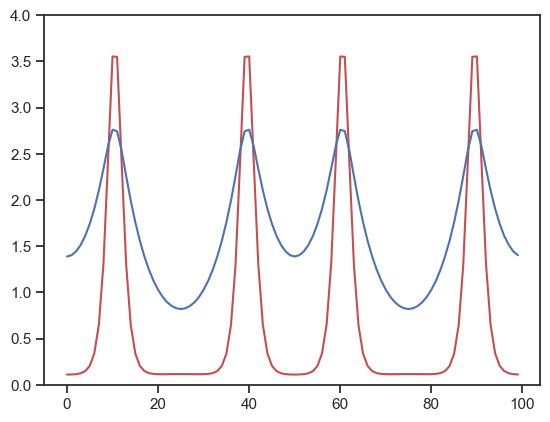

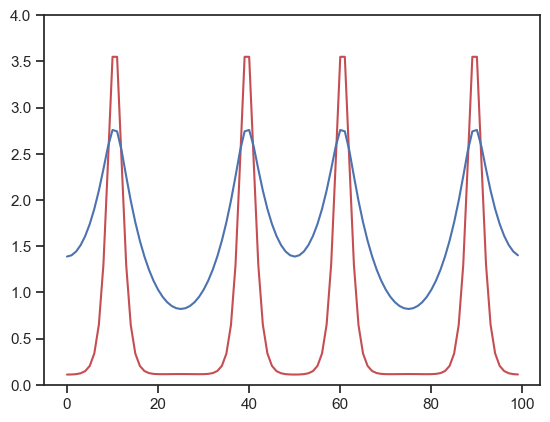

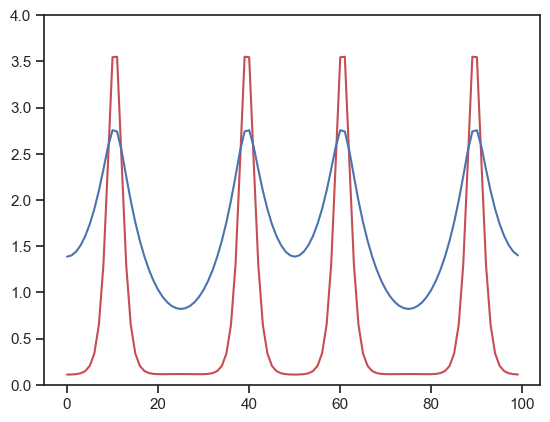

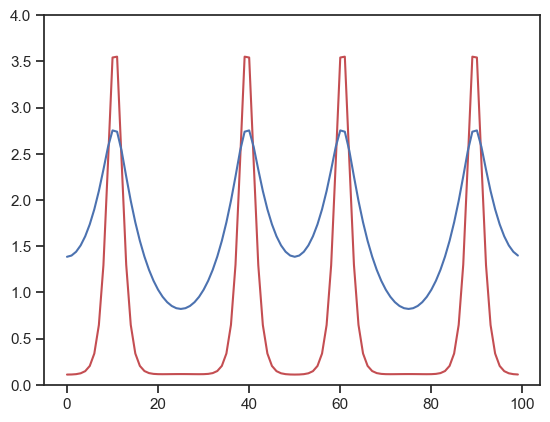

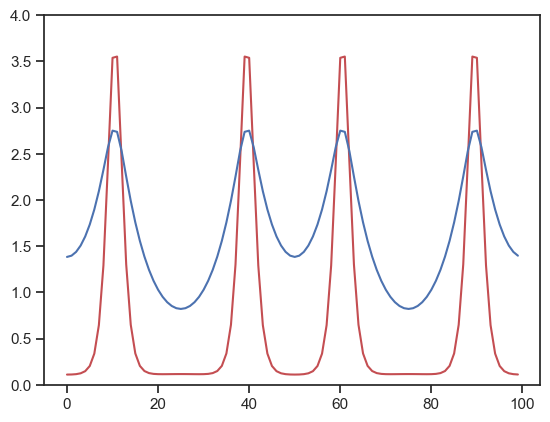

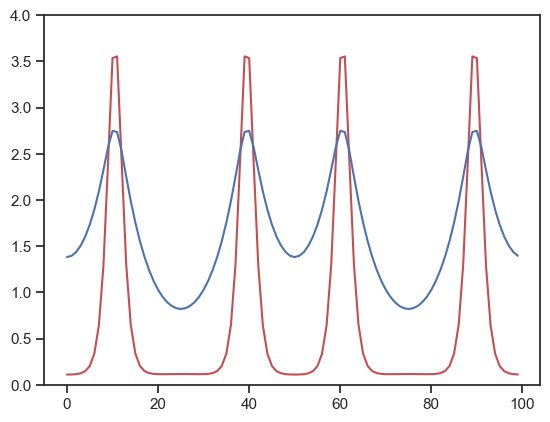

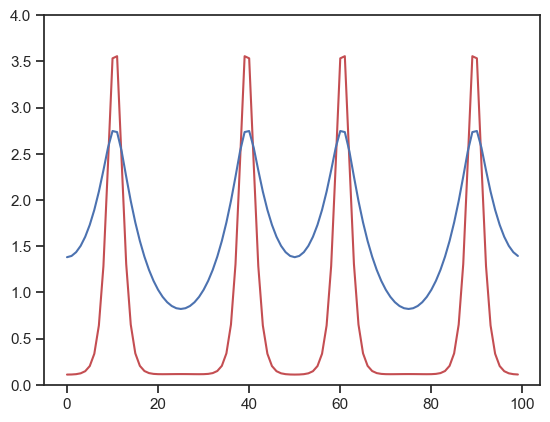

In [141]:
for x in range(1,500):  
    u,v = CNIntegrator(u1,v1,u0,v0,matrix,D)
    if x%20==0:
            plt.plot(X,u0,'r')
            plt.plot(X,v0,'b')
            plt.ylim([0,4])
            plt.show()
    elif x==1:
            plt.plot(X,u0,'r')
            plt.plot(X,v0,'b')
            plt.ylim([0,4])
            plt.show()
    u1,v1,u0,v0 = u,v,u1,v1

In [271]:
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreqq

In [157]:
k0=0.5
X = np.arange(0,N)
ru=np.cos(k0*X)
rv=np.cos(k0*X)
U = u_star+ru
V = u_star**2+rv
delta_t = 0.01
D=np.array([0.1,1,5,10,20,30,40,50,60,70,80,90,100])


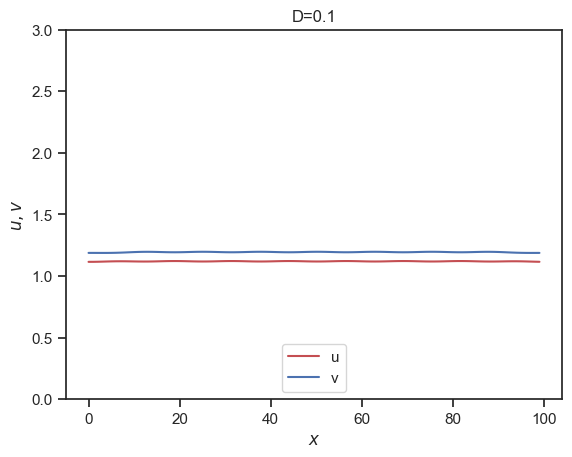

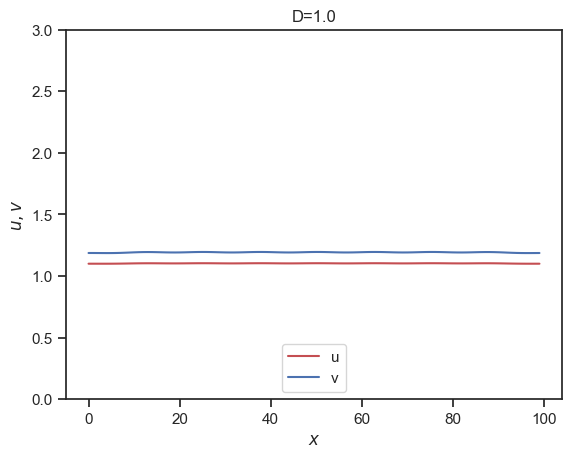

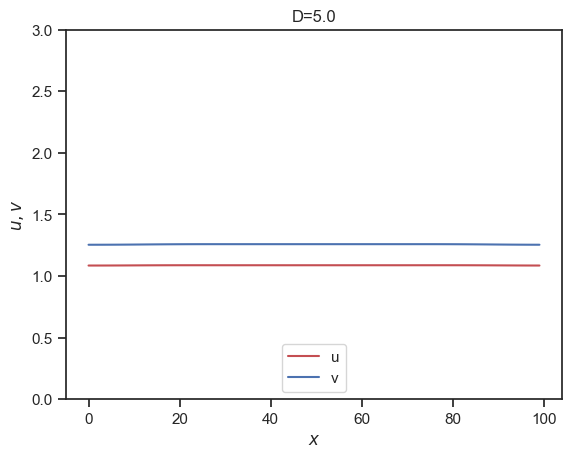

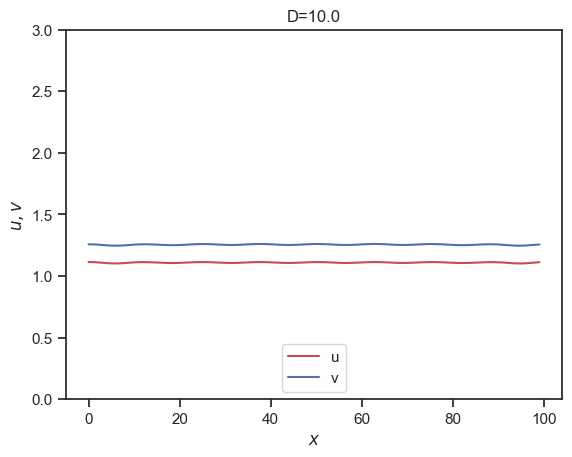

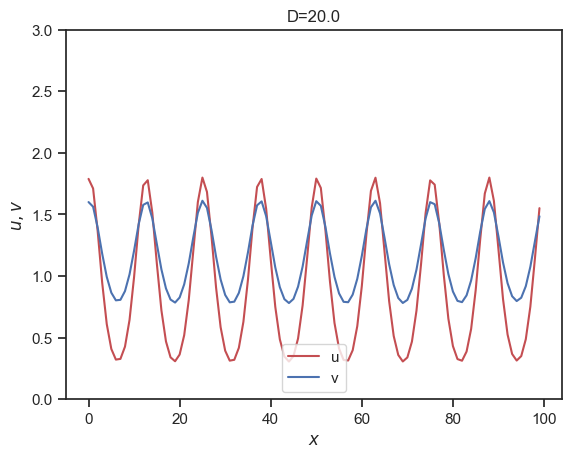

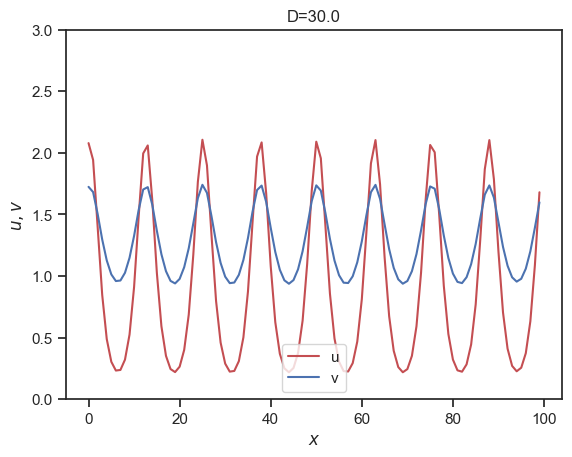

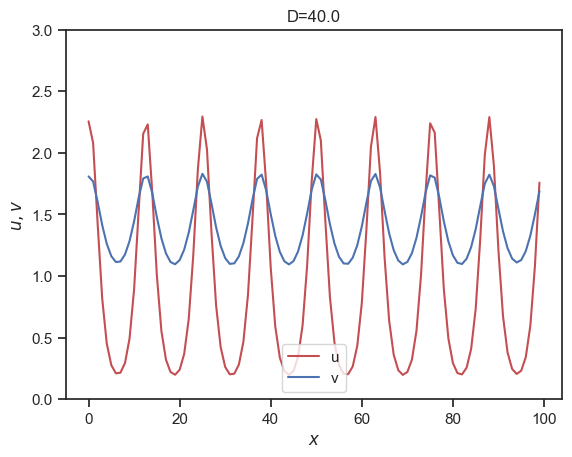

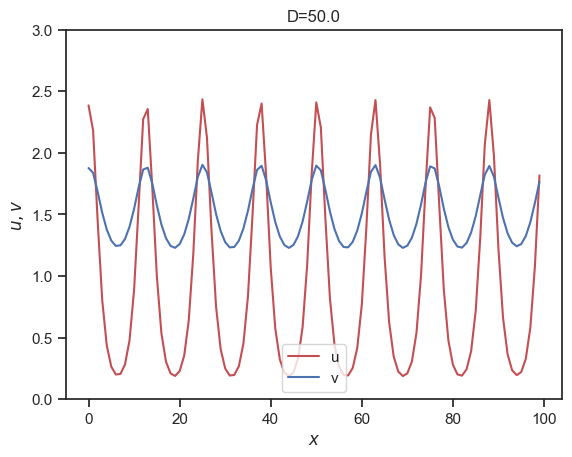

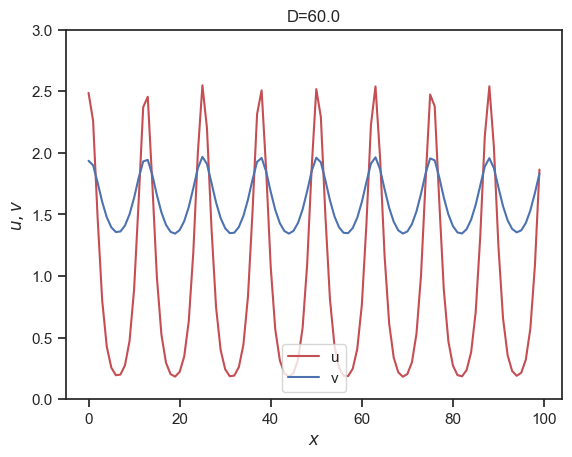

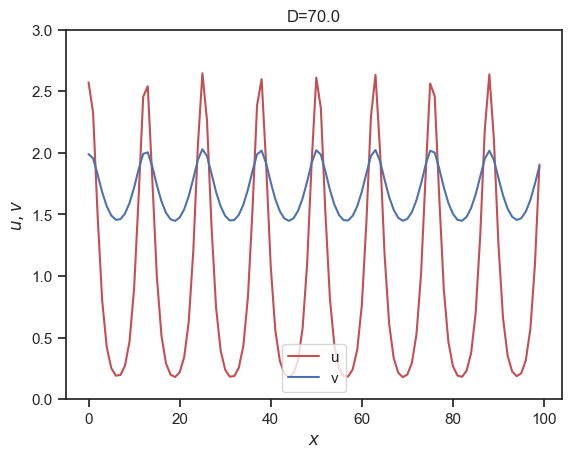

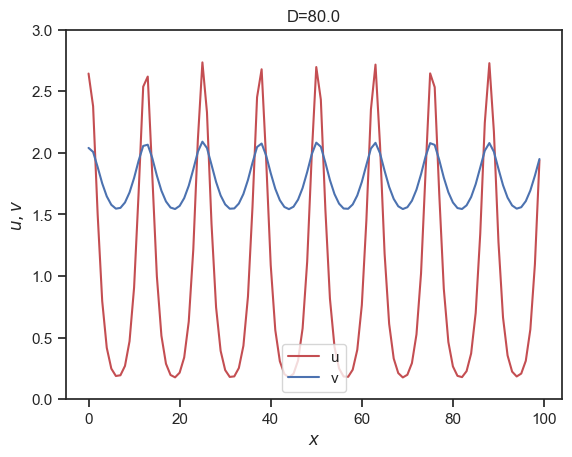

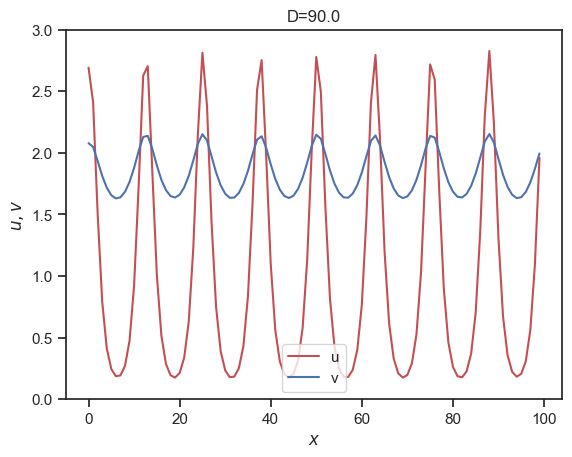

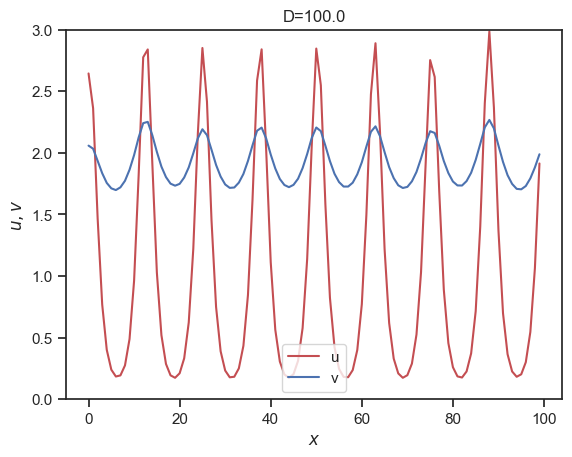

In [167]:
for d in D:
    u0 = U
    v0 = V
    u1=u0+delta_t*dudt(matrix,u0,v0)
    v1=v0+delta_t*dvdt(matrix,u0,v0,d)
    for x in range(1,2000):  
        u,v = CNIntegrator(u1,v1,u0,v0,matrix,d)
        u1,v1,u0,v0 = u,v,u1,v1
    plt.plot(X,u0,'r')
    plt.plot(X,v0,'b')
    plt.ylim([0,3])
    plt.legend((["u","v"]),loc="lower center")
    plt.xlabel(r"$x$")
    plt.ylabel(r"$u,v$")
    plt.title(f'D={d}')
    plt.savefig(f'CN D={d}.jpg',bbox_inches='tight')
    plt.show()
